# 문장분류를 위한 CNN모델
'문장'을 '감정 클래스별'로 분류하는CNN 모델 구현
- CNN 은 이미지 분류 외에도 자연어 분류에도 좋은 성능을 냅니다 (단 **임베딩 품질**이 좋아야 함.)
- 이미지 이든, 자연어이든  수치(벡터) 로 표현 가능한 대상이면, 특징을 뽑아내도록 CNN 모델 학습인 가능한겁니다

In [1]:
# 필요한 모듈 임포트
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import preprocessing

# 실행마다 동일한 결과를 얻기 위해 keras 에 랜덤시드 사용
tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

# CNN 모델 생성용 ↓
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Dense, Dropout, Conv1D, GlobalMaxPool1D, concatenate



# 데이터 준비

In [48]:
base_path = r'/content/drive/MyDrive'

In [6]:
data = pd.read_csv(os.path.join(base_path, 'chatbot_data', 'chatbot_data.csv'))

data

,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0
...,...,...,...
11818,훔쳐보는 것도 눈치 보임.,티가 나니까 눈치가 보이는 거죠!,2
11819,훔쳐보는 것도 눈치 보임.,훔쳐보는 거 티나나봐요.,2
11820,흑기사 해주는 짝남.,설렜겠어요.,2
11821,힘든 연애 좋은 연애라는게 무슨 차이일까?,잘 헤어질 수 있는 사이 여부인 거 같아요.,2


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


- 데이터셋 구조
    - Q (질문),  
    - A (답변)
    - label (감정)
        - **0**: 일상다반사
        - **1** : 이별(부정)
        - **2** : 사랑(긍정)

In [8]:
data.shape

(11823, 3)

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11823 entries, 0 to 11822
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Q       11823 non-null  object
 1   A       11823 non-null  object
 2   label   11823 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 277.2+ KB


In [10]:
data['label'].unique()

array([0, 1, 2])

In [11]:
data['label'].value_counts()

,count
label,
0,5290
1,3570
2,2963


In [12]:
features = data['Q'].tolist()
labels = data['label'].tolist()

In [13]:
features[0]

'12시 땡!'

# 단어 시퀀스 만들기


## text_to_word_sequence()

**tf.keras.preprocessing.text.text_to_word_sequence()**

단어 시퀀스를 만든다.  단어 시퀀스란 단어 토큰들의 순차적 리스트

https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/text/text_to_word_sequence

```python
tf.keras.preprocessing.text.text_to_word_sequence(
    input_text,
    filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',
    lower=True,
    split=' '
)
```

리턴값: A list of words (or tokens).

In [14]:
preprocessing.text.text_to_word_sequence(features[0])

['12시', '땡']

In [15]:
# 단어 시퀀스 들의 벡터
corpus = [
    preprocessing.text.text_to_word_sequence(text) for text in features
]

corpus

[['12시', '땡'],
 ['1지망', '학교', '떨어졌어'],
 ['3박4일', '놀러가고', '싶다'],
 ['3박4일', '정도', '놀러가고', '싶다'],
 ['ppl', '심하네'],
 ['sd카드', '망가졌어'],
 ['sd카드', '안돼'],
 ['sns', '맞팔', '왜', '안하지ㅠㅠ'],
 ['sns', '시간낭비인', '거', '아는데', '매일', '하는', '중'],
 ['sns', '시간낭비인데', '자꾸', '보게됨'],
 ['sns보면', '나만', '빼고', '다', '행복해보여'],
 ['가끔', '궁금해'],
 ['가끔', '뭐하는지', '궁금해'],
 ['가끔은', '혼자인게', '좋다'],
 ['가난한', '자의', '설움'],
 ['가만', '있어도', '땀난다'],
 ['가상화폐', '쫄딱', '망함'],
 ['가스불', '켜고', '나갔어'],
 ['가스불', '켜놓고', '나온거', '같아'],
 ['가스비', '너무', '많이', '나왔다'],
 ['가스비', '비싼데', '감기', '걸리겠어'],
 ['가스비', '장난', '아님'],
 ['가장', '확실한', '건', '뭘까'],
 ['가족', '여행', '가기로', '했어'],
 ['가족', '여행', '고고'],
 ['가족', '여행', '어디로', '가지'],
 ['가족', '있어'],
 ['가족관계', '알려', '줘'],
 ['가족끼리', '여행간다'],
 ['가족들', '보고', '싶어'],
 ['가족들이랑', '서먹해'],
 ['가족들이랑', '서먹해졌어'],
 ['가족들이랑', '어디', '가지'],
 ['가족들이랑', '여행', '갈거야'],
 ['가족여행', '가야지'],
 ['가족이', '누구야'],
 ['가족이랑', '여행', '가려고'],
 ['가족한테', '스트레스', '풀었어'],
 ['가출할까'],
 ['가출해도', '갈', '데가', '없어'],
 ['간만에', '떨리니까', '좋더라'],
 ['간만에', '쇼핑', '

## Tokenizer

In [16]:
tokenizer = preprocessing.text.Tokenizer()

In [17]:
tokenizer.fit_on_texts(corpus)

In [18]:
tokenizer.word_index

{'너무': 1,
 '좋아하는': 2,
 '거': 3,
 '싶어': 4,
 '같아': 5,
 '안': 6,
 '나': 7,
 '좀': 8,
 '사람': 9,
 '내가': 10,
 '싶다': 11,
 '어떻게': 12,
 '썸': 13,
 '왜': 14,
 '내': 15,
 '사람이': 16,
 '이별': 17,
 '것': 18,
 '잘': 19,
 '없어': 20,
 '수': 21,
 '오늘': 22,
 '자꾸': 23,
 '이제': 24,
 '있어': 25,
 '또': 26,
 '많이': 27,
 '다': 28,
 '있을까': 29,
 '헤어진지': 30,
 '해': 31,
 '다시': 32,
 '될까': 33,
 '여자친구가': 34,
 '남자친구가': 35,
 '더': 36,
 '진짜': 37,
 '정말': 38,
 '게': 39,
 '나를': 40,
 '뭐': 41,
 '좋아': 42,
 '할까': 43,
 '하고': 44,
 '하는': 45,
 '연애': 46,
 '있는': 47,
 '계속': 48,
 '힘드네': 49,
 '연락': 50,
 '이': 51,
 '나만': 52,
 '먹고': 53,
 '이렇게': 54,
 '있는데': 55,
 '못': 56,
 '날': 57,
 '혼자': 58,
 '다른': 59,
 '방법': 60,
 '타는': 61,
 '한': 62,
 '그': 63,
 '안돼': 64,
 '그냥': 65,
 '없는': 66,
 '돼': 67,
 '짝남이': 68,
 '좋겠다': 69,
 '선물': 70,
 '모르겠어': 71,
 '같이': 72,
 '나한테': 73,
 '같은데': 74,
 '싫어': 75,
 '친구가': 76,
 '마음이': 77,
 '짝사랑': 78,
 '가고': 79,
 '사랑': 80,
 '헤어진': 81,
 '많아': 82,
 '힘들어': 83,
 '연락이': 84,
 '줄': 85,
 '좋겠어': 86,
 '술': 87,
 '후': 88,
 '짝남': 89,
 '듯': 90,
 '좋은': 91,
 '좋을까

## texts_to_sequence()

In [19]:
sequences = tokenizer.texts_to_sequences(corpus)
sequences

[[4646, 4647],
 [4648, 343, 448],
 [2580, 803, 11],
 [2580, 804, 803, 11],
 [4649, 2581],
 [2582, 4650],
 [2582, 64],
 [805, 4651, 14, 4652],
 [805, 4653, 3, 502, 238, 45, 106],
 [805, 4654, 23, 4655],
 [4656, 52, 1128, 28, 1373],
 [693, 266],
 [693, 2583, 266],
 [2584, 4657, 324],
 [4658, 4659, 4660],
 [4661, 1129, 2585],
 [4662, 4663, 1374],
 [2586, 4664, 1375],
 [2586, 4665, 2587, 5],
 [1811, 1, 27, 4666],
 [1811, 2588, 1130, 4667],
 [1811, 628, 1131],
 [944, 1812, 154, 128],
 [1132, 176, 1376, 184],
 [1132, 176, 1133],
 [1132, 176, 945, 1813],
 [1132, 25],
 [2589, 4668, 503],
 [2590, 4669],
 [4670, 94, 4],
 [1377, 4671],
 [1377, 4672],
 [1377, 368, 1813],
 [1377, 176, 4673],
 [4674, 280],
 [2591, 1378],
 [4675, 176, 1379],
 [2592, 253, 4676],
 [4677],
 [4678, 504, 1380, 20],
 [1381, 4679, 1814],
 [1381, 1134, 106],
 [1381, 2593, 106],
 [1815, 41, 405],
 [1815, 254],
 [4680, 2594],
 [4681, 75],
 [325, 505, 308, 67],
 [325, 505],
 [2595, 2596, 53, 11],
 [2595, 2596, 185],
 [1130, 109

In [20]:
corpus[0], sequences[0]

(['12시', '땡'], [4646, 4647])

In [21]:
corpus[8], sequences[8]

(['sns', '시간낭비인', '거', '아는데', '매일', '하는', '중'],
 [805, 4653, 3, 502, 238, 45, 106])

## .word_index 단어사전

In [22]:
word_index = tokenizer.word_index

In [23]:
len(word_index)

13398

In [24]:
# 다른 문장으로 테스트
tokenizer.texts_to_sequences([
    ['여기', '어때'],
    ['정말', '좋아'],
    ['온달', '장군'],
])

[[2147, 108], [38, 42], []]

## pad_sequences()

In [25]:
max([len(words) for words in corpus])

15

In [26]:
# 가장 긴 문장의 토큰 길이가 15 <- 이 길이로 패딩 진행.
MAX_SEQ_LEN = 15

In [27]:
padded_seqs = preprocessing.sequence.pad_sequences(
    sequences,
    maxlen=MAX_SEQ_LEN,
    padding='post'
)

padded_seqs

array([[ 4646,  4647,     0, ...,     0,     0,     0],
       [ 4648,   343,   448, ...,     0,     0,     0],
       [ 2580,   803,    11, ...,     0,     0,     0],
       ...,
       [13395,  2517,    89, ...,     0,     0,     0],
       [  147,    46,    91, ...,     0,     0,     0],
       [  555, 13398,     0, ...,     0,     0,     0]], dtype=int32)

In [28]:
print(corpus[0])
print(sequences[0])
print(padded_seqs[0])

['12시', '땡']
[4646, 4647]
[4646 4647    0    0    0    0    0    0    0    0    0    0    0    0
    0]


# Dataset 객체 만들기

In [29]:
# 위에 패딩 처리된 시퀀스 (padded_seqs) 의 벡터 리스트와 감정(label) 리스트 전체를
# TF의 Dataset 객체로 만든다
# 그리고 데이터를 랜덤으로 섞고, train, validation, test 용
# 데이터 셋을 7:2:1 비율로 나눠 데이터셋을 각각 분리합니다
# 그리고 batch 로 묶겠습니다

In [30]:
padded_seqs.shape

(11823, 15)

In [31]:
ds = tf.data.Dataset.from_tensor_slices((padded_seqs, labels))

In [32]:
# Dataset 의 첫번째 값 (data, target)

iter(ds).get_next()

(<tf.Tensor: shape=(15,), dtype=int32, numpy=
 array([4646, 4647,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0], dtype=int32)>,
 <tf.Tensor: shape=(), dtype=int32, numpy=0>)

In [33]:
# 랜덤 섞기
ds = ds.shuffle(len(features), seed=42)

In [34]:
# train: val: test = 7:2:1

train_size = int(len(padded_seqs) * 0.7)
val_size = int(len(padded_seqs) * 0.2)
test_size = int(len(padded_seqs) * 0.1)

len(ds), train_size, val_size, test_size

(11823, 8276, 2364, 1182)

In [35]:
train_ds = ds.take(train_size).batch(20)
val_ds = ds.skip(train_size).take(val_size).batch(20)
test_ds = ds.skip(train_size + val_size).batch(20)

In [36]:
# ↑ fit(), evaluate(), predict() 의 입력에 사용될수 있다.

In [37]:
len(train_ds), len(val_ds), len(test_ds)

# (414, 119, 60) <-- 데이터의 개수가 아니라 batch 의 개수!

(414, 119, 60)

# 모델 생성
- 문장 감정 클래스 분류 모델

In [38]:
# 하이퍼 파라미터 설정
dropout_prob = 0.5
EMB_SIZE = 128
EPOCH = 5
VOCAB_SIZE = len(word_index) + 1  # 전체 단어수

## Embedding 레이어
**tf.keras.layers.Embedding**

https://www.tensorflow.org/api_docs/python/tf/keras/layers/Embedding

```python
tf.keras.layers.Embedding(
    input_dim,
    output_dim,
    embeddings_initializer='uniform',
    embeddings_regularizer=None,
    embeddings_constraint=None,
    mask_zero=False,
    weights=None,
    lora_rank=None,
    **kwargs
)
```

In [39]:
# CNN 모델 정의

# ▶ 1. 단어 임베딩 영역
input_layer = Input(shape=(MAX_SEQ_LEN,))

embedding_layer = Embedding(
    VOCAB_SIZE,
    EMB_SIZE,
)(input_layer)

dropout_emb = Dropout(rate=dropout_prob)(embedding_layer)

# ▶ 2. 특징 추출 영역 ( feature extraction)
#    합성곱 필터와 연산을 통해 문장의 '특징정보(feature map)을 추출' ...  => flatten
#    Conv1D 를 이용해 크기 3, 4, 5 인 합성곱 필터를 128개씩 사용한 합성곱 계층을 3개 생성
#    합성곱 연산 과정 : 필터 크기에 맞게 입력 데이터 위를 슬라이딩 하게 되는데 이는 3, 4, 5-gram 언어 모델의 개념과 비슷
#    입베딩 벡터를 합성곱으로 받아 GlobalMaxPool1D () 를 이용해 최대 max pooling 연산 수행
#    각각 '병렬'로 진행

conv1 = Conv1D(filters=128, kernel_size=3, padding='valid', activation='relu')(dropout_emb)
pool1 = GlobalMaxPool1D()(conv1)

conv2 = Conv1D(filters=128, kernel_size=4, padding='valid', activation='relu')(dropout_emb)
pool2 = GlobalMaxPool1D()(conv2)

conv3 = Conv1D(filters=128, kernel_size=5, padding='valid', activation='relu')(dropout_emb)
pool3 = GlobalMaxPool1D()(conv3)

concat = concatenate([pool1, pool2, pool3])

# ▶ 3. 완전연결계층 (Full connected layer)

hidden = Dense(128, activation='relu')(concat)
dropout_hidden = Dropout(rate=dropout_prob)(hidden)

predictions = Dense(3, activation='softmax')(dropout_hidden)

model = Model(inputs=input_layer, outputs=predictions)

model.summary()






Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 15)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 15, 128)   │  1,715,072 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 15, 128)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 13, 128)   │     49,280 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 12, 128)   │     65,664 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 11, 128)   │     82,048 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     49,280 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │        387 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,961,731 (7.48 MB)

 Trainable params: 1,961,731 (7.48 MB)

 Non-trainable params: 0 (0.00 B)

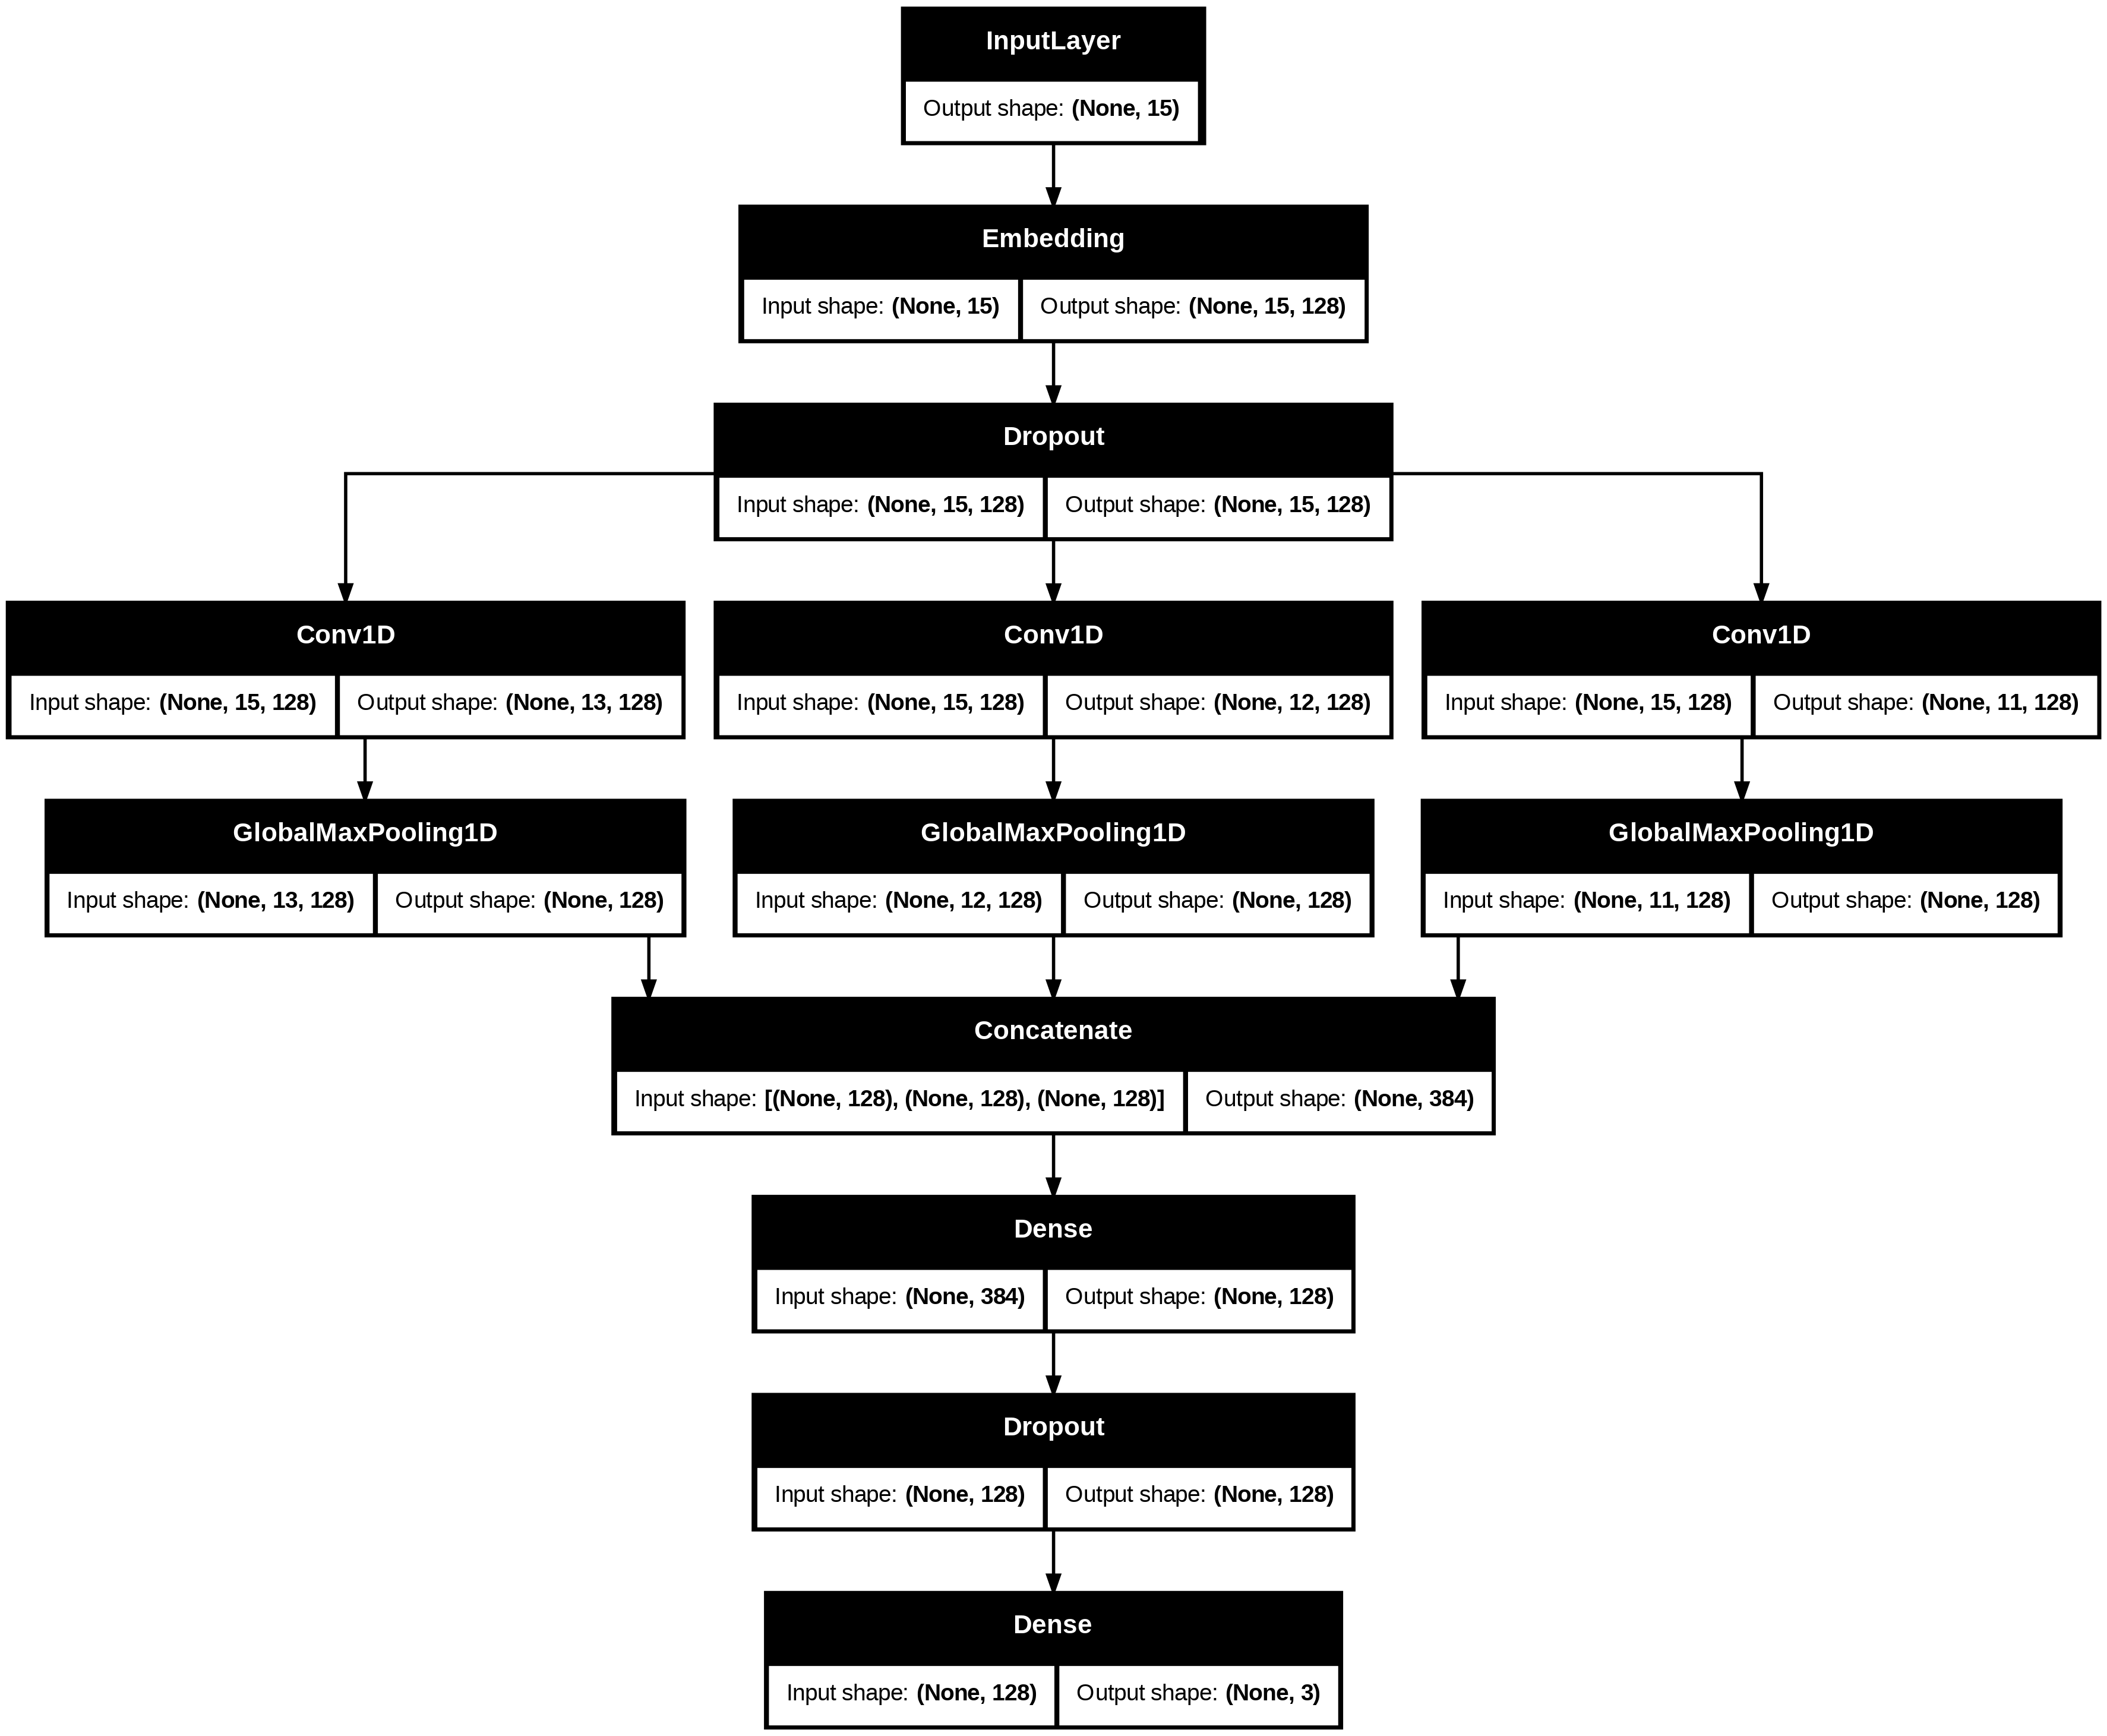

In [40]:
tf.keras.utils.plot_model(model, show_shapes=True)

# 모델 컴파일 & 학습

In [41]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [42]:
model.fit(train_ds, validation_data=val_ds, epochs=EPOCH)

Epoch 1/5
414/414 ━━━━━━━━━━━━━━━━━━━━ 16s 30ms/step - accuracy: 0.5042 - loss: 0.9776 - val_accuracy: 0.8228 - val_loss: 0.5026
Epoch 2/5
414/414 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.8071 - loss: 0.5163 - val_accuracy: 0.9234 - val_loss: 0.2583
Epoch 3/5
414/414 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.9047 - loss: 0.2913 - val_accuracy: 0.9585 - val_loss: 0.1368
Epoch 4/5
414/414 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.9488 - loss: 0.1623 - val_accuracy: 0.9759 - val_loss: 0.0887
Epoch 5/5
414/414 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.9661 - loss: 0.1141 - val_accuracy: 0.9805 - val_loss: 0.0659


# 성능평가

In [43]:
loss, accuracy = model.evaluate(test_ds)

print('loss', loss)
print('accuracy', accuracy)

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9738 - loss: 0.0715
loss 0.05566059425473213
accuracy 0.9830938577651978


# 저장하기

In [44]:
# 학습된 모델도 저장하고
# 학습에 사용한 사전정보도 저장해야 한다.

In [49]:
base_path

'/content/drive/MyDrive'

In [50]:
model_path = os.path.join(base_path, 'out', 'cnn_model.keras')
tokenizer_path = os.path.join(base_path, 'out', 'cnn-model-tokenizer.json')

In [52]:
# 모델 저장
model.save(model_path)

In [53]:
# 사전저장
# tf.keras.preprocessing.text.Tokenizer를 저장하고 다시 불러오는 방법은
# json 또는 pickle 형식으로 할 수 있습니다.

# 📌 주의: Pickle 방식은 Python 버전, TensorFlow 버전에 따라 호환성 문제가 생길 수 있습니다.
# 그래서 json 방식이 더 권장되는 편이다, 특히! 모델 배포 시!

In [54]:
tokenizer_json = tokenizer.to_json()
with open(tokenizer_path, "w", encoding='utf-8') as f:
  f.write(tokenizer_json)

# 감정분류 모델 사용하기

## 모델, 사전 불러오기

In [55]:
model = None
tokenizer = None

In [56]:
# 모델 불러오기
model = keras.models.load_model(model_path)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 15)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 15, 128)   │  1,715,072 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 15, 128)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 13, 128)   │     49,280 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 12, 128)   │     65,664 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 11, 128)   │     82,048 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     49,280 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │        387 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,885,195 (22.45 MB)

 Trainable params: 1,961,731 (7.48 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,923,464 (14.97 MB)

In [57]:
# 사전 불러오기
from tensorflow.keras.preprocessing.text import tokenizer_from_json
import json

In [58]:
# JSON 파일 읽기
with open(tokenizer_path, 'r', encoding='utf-8') as f:
  tokenizer_json = f.read()

# Tokenizer 복원
tokenizer = tokenizer_from_json(tokenizer_json)


In [59]:
tokenizer.word_index

{'너무': 1,
 '좋아하는': 2,
 '거': 3,
 '싶어': 4,
 '같아': 5,
 '안': 6,
 '나': 7,
 '좀': 8,
 '사람': 9,
 '내가': 10,
 '싶다': 11,
 '어떻게': 12,
 '썸': 13,
 '왜': 14,
 '내': 15,
 '사람이': 16,
 '이별': 17,
 '것': 18,
 '잘': 19,
 '없어': 20,
 '수': 21,
 '오늘': 22,
 '자꾸': 23,
 '이제': 24,
 '있어': 25,
 '또': 26,
 '많이': 27,
 '다': 28,
 '있을까': 29,
 '헤어진지': 30,
 '해': 31,
 '다시': 32,
 '될까': 33,
 '여자친구가': 34,
 '남자친구가': 35,
 '더': 36,
 '진짜': 37,
 '정말': 38,
 '게': 39,
 '나를': 40,
 '뭐': 41,
 '좋아': 42,
 '할까': 43,
 '하고': 44,
 '하는': 45,
 '연애': 46,
 '있는': 47,
 '계속': 48,
 '힘드네': 49,
 '연락': 50,
 '이': 51,
 '나만': 52,
 '먹고': 53,
 '이렇게': 54,
 '있는데': 55,
 '못': 56,
 '날': 57,
 '혼자': 58,
 '다른': 59,
 '방법': 60,
 '타는': 61,
 '한': 62,
 '그': 63,
 '안돼': 64,
 '그냥': 65,
 '없는': 66,
 '돼': 67,
 '짝남이': 68,
 '좋겠다': 69,
 '선물': 70,
 '모르겠어': 71,
 '같이': 72,
 '나한테': 73,
 '같은데': 74,
 '싫어': 75,
 '친구가': 76,
 '마음이': 77,
 '짝사랑': 78,
 '가고': 79,
 '사랑': 80,
 '헤어진': 81,
 '많아': 82,
 '힘들어': 83,
 '연락이': 84,
 '줄': 85,
 '좋겠어': 86,
 '술': 87,
 '후': 88,
 '짝남': 89,
 '듯': 90,
 '좋은': 91,
 '좋을까

## 평가

In [60]:
ds = tf.data.Dataset.from_tensor_slices((padded_seqs, labels))
ds = ds.shuffle(len(features), seed=42)
test_ds = ds.take(2000).batch(20)

In [61]:
loss, accuracy = model.evaluate(test_ds)

print(loss, accuracy)

100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9762 - loss: 0.0809
0.07436700165271759 0.9779999852180481


## 예측

In [62]:
i = 10212
print(corpus[i])
print(padded_seqs[i])
print(labels[i])

['썸', '타는', '여자가', '남사친', '만나러', '간다는데', '뭐라', '해']
[   13    61   127  4320  1333 12162   856    31     0     0     0     0
     0     0     0]
2


In [63]:
# i번째 데이터 감정 예측
picks = [i]

predict = model.predict(padded_seqs[picks])
predict_class = tf.math.argmax(predict, axis=1)

print('감정 예측 점수: ', predict)
print('감정 예측 클래스: ', predict_class.numpy())



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
감정 예측 점수:  [[6.9041369e-07 3.7825400e-06 9.9999547e-01]]
감정 예측 클래스:  [2]


## 실제 데이터 예측

In [64]:
# 문장 =>
#     Tokenizer 로 인덱싱 =>
#          padding 추가 =>  모델입력

In [65]:
classes = ['일상', '부정적', '긍정적']

In [66]:
MAX_SEQ_LEN

15

In [67]:
def pred(text):
  corpus = [preprocessing.text.text_to_word_sequence(text)]
  sequences = tokenizer.texts_to_sequences(corpus)
  padded_seqs = preprocessing.sequence.pad_sequences(sequences, maxlen=MAX_SEQ_LEN, padding='post')

  predict = model.predict(padded_seqs)
  predict_class = tf.math.argmax(predict, axis=1)

  print(text, '->', classes[predict_class.numpy()[0]])

In [68]:
pred("내가 좋아하는 사람이 날 좋아했으면 좋겠어.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
내가 좋아하는 사람이 날 좋아했으면 좋겠어. -> 긍정적


In [69]:
sentences = [
    "가스불 켜놓고 나온거 같아",
    "어떻게 해야 여자친구가 제 진심을 알아줄까",
    "업무 스트레스 넘 심해",
    "남친이랑 뭐하고 놀지",
    "내가 좋아하는 사람이 날 좋아했으면 좋겠어.",
    "원본 데이터가 이상해요",
    "내가 최대한 잘해줘도 불만이 많아",
]

In [70]:
for sentence in sentences:
  pred(sentence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
가스불 켜놓고 나온거 같아 -> 일상
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
어떻게 해야 여자친구가 제 진심을 알아줄까 -> 부정적
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
업무 스트레스 넘 심해 -> 일상
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
남친이랑 뭐하고 놀지 -> 긍정적
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
내가 좋아하는 사람이 날 좋아했으면 좋겠어. -> 긍정적
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
원본 데이터가 이상해요 -> 부정적
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
내가 최대한 잘해줘도 불만이 많아 -> 긍정적
